In [128]:
import pandas as pd
import numpy as np
import pyreadr
from scipy.interpolate import interp1d

In [745]:
load = pyreadr.read_r("c:\\Users\\Maxim\\dsi-capstone-fall-2024-team-forecasting-treasury-yield\\Data\\cleaned_monthly_data.RData")

In [746]:
monthly_1985 = load['monthly_1985']
monthly_1985['yield_5yr_ahead'] = monthly_1985['tenyr_yield'].shift(-60)
monthly_1985 = monthly_1985.dropna()

y = monthly_1985[['month', 'yield_5yr_ahead']]
features = monthly_1985.drop(columns=['yield_5yr_ahead'])

In [ ]:
#TRY INCLUDING SOME MOVING AVERAGES

In [734]:
def compute_ecdf(y, test_values):
    cdf_values = np.zeros_like(test_values, dtype=float)
    for i, y_test in enumerate(test_values):
        cdf_values[i] = np.mean(y > y_test)
    return cdf_values

In [735]:
def sample_from_cdf(y, num_samples=1):
    # Define test values for ECDF within the range of current window
    test_values = np.linspace(y.min() - 5, y.max() + 5, 200)
    
    standard_cdf_values = 1 - compute_ecdf(y, test_values)

    inverse_cdf = interp1d(standard_cdf_values, test_values, bounds_error=False, fill_value=(test_values[0], test_values[-1]))
    
    #Sample from the CDF
    u = np.random.rand(num_samples)
    samples = inverse_cdf(u)
    return samples

In [736]:
def synthetic_time_series(data, window_size, num_samples_per_window):
    synthetic_data = {} 
    features = data.drop(columns=['month']) 
    
    for column in features.columns: 
        feature_data = features[column] 
        synthetic_feature_data = [] 
        syntheitc_months = []

        for start in range(len(feature_data) - window_size): 
            window = feature_data[start:start + window_size] 
            new_samples = sample_from_cdf(window, num_samples=num_samples_per_window) 
            synthetic_feature_data.append(new_samples) 

            month_value = data['month'].iloc[start + window_size] 
            syntheitc_months.extend([month_value] * num_samples_per_window)
 
        synthetic_feature_data = np.concatenate(synthetic_feature_data) 
        synthetic_data[column] = synthetic_feature_data 

    augmented_df = pd.DataFrame(synthetic_data) 
    augmented_df['month'] = syntheitc_months
    return augmented_df

In [747]:
#Idea: Sample from both a short-term CDF and a long-term CDF to get 
shortterm_synthetic_data = synthetic_time_series(features, 12, 5)

In [748]:
longterm_synthetic_data = synthetic_time_series(features, 60, 15)

In [749]:
shortterm_synthetic_data = shortterm_synthetic_data[shortterm_synthetic_data["month"] >= min(longterm_synthetic_data["month"])]
synthetic_data = pd.concat([longterm_synthetic_data, shortterm_synthetic_data]).sort_values(by="month", ascending=True)

real_data = features[features["month"] >= min(synthetic_data["month"])]
full_data = pd.concat([synthetic_data, real_data]).sort_values(by="month", ascending=True)

y = y[y["month"] >= min(synthetic_data["month"])]
features = features[features["month"] >= min(synthetic_data["month"])]

A few strategies to try: 

Treat each row as a separate training point.

The samples at each timestep interact? i.e. each initial neuron is one of the 21 samples (these would be cubes of 
    (batch_size, sample_size, feature_size))

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from sklearn.preprocessing import StandardScaler

In [750]:
full_data = pd.merge(full_data, y, on="month")

In [754]:
#Start with 10 years of training data
# 10 * 12 * 21 - 1 = 2519

train_data = full_data.iloc[0:2519]

#Validation data will be 21 points after the last training y (1 month)
# 2519 + 21 * 12 * 5 + 1 = 3780

val_data = full_data.iloc[3780:3800]


y_train = train_data['yield_5yr_ahead']
X_train = train_data.drop(columns=['yield_5yr_ahead', 'month'])

y_val = val_data['yield_5yr_ahead']
X_val = val_data.drop(columns=['yield_5yr_ahead', 'month'])

X_test = features.drop(columns=['month']).iloc[160:161]
y_test = y.drop(columns=['month']).iloc[160:161]

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [755]:
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [756]:
train_dataset = TimeSeriesDataset(X_train_scaled, np.array(y_train))
val_dataset = TimeSeriesDataset(X_val_scaled, np.array(y_val))
test_dataset = TimeSeriesDataset(X_test_scaled, np.array(y_test))

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [798]:
class TimeSeriesNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(TimeSeriesNN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, hidden_size)
        self.fc4 = nn.Linear(hidden_size, output_size)
        self.droupout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.fc1(x)
        x = nn.ReLU()(x)
        x = self.droupout(x)
        x = self.fc2(x)
        x = nn.ReLU()(x)
        x = self.droupout(x)
        x = self.fc3(x)
        x = nn.ReLU()(x)
        x = self.droupout(x)
        x = self.fc4(x)
        return x
    
    


In [ ]:
#One hidden layer no dropout
model = TimeSeriesNN(X_train_scaled.shape[1], 16, 1)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [759]:
num_epochs = 50
for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()

        preds = model.forward(X_batch).squeeze()

        loss = criterion(preds, y_batch)
        train_loss += loss.item()

        loss.backward()
        optimizer.step()

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            preds = model.forward(X_batch).squeeze()
            
            loss = criterion(preds, y_batch)
            val_loss += loss.item()
    
    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss/len(train_loader)}, Val Loss: {val_loss/len(val_loader)}")

Epoch 1/50, Train Loss: 23.355166167020798, Val Loss: 17.664663314819336
Epoch 2/50, Train Loss: 4.907193368673324, Val Loss: 3.7888894081115723
Epoch 3/50, Train Loss: 5.356079939007759, Val Loss: 22.817096710205078
Epoch 4/50, Train Loss: 8.040557610988618, Val Loss: 24.588224411010742
Epoch 5/50, Train Loss: 4.917435067892074, Val Loss: 15.248636245727539
Epoch 6/50, Train Loss: 3.3581907004117966, Val Loss: 13.349520683288574
Epoch 7/50, Train Loss: 3.2521197468042375, Val Loss: 11.774825096130371
Epoch 8/50, Train Loss: 2.9494352877140044, Val Loss: 7.6906585693359375
Epoch 9/50, Train Loss: 2.9429838091135023, Val Loss: 6.5709028244018555
Epoch 10/50, Train Loss: 2.7099155455827715, Val Loss: 7.287650108337402
Epoch 11/50, Train Loss: 2.639678181707859, Val Loss: 6.932837009429932
Epoch 12/50, Train Loss: 2.5565104976296427, Val Loss: 5.375058650970459
Epoch 13/50, Train Loss: 2.424040658771992, Val Loss: 3.897822856903076
Epoch 14/50, Train Loss: 2.2921685934066773, Val Loss: 3.

In [760]:
model.eval()
test_loss = 0.0
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        predictions = model(X_batch)
        print("predictions:")
        print(predictions)
        print("real value")
        print(y_batch)
        loss = criterion(predictions, y_batch)
        test_loss += loss.item()

print(f"Test Loss: {test_loss/len(test_loader)}")



predictions:
tensor([[3.9461]])
real value
tensor([[3.8745]])
Test Loss: 0.005123618524521589


In [743]:
len(full_data)

7518

In [799]:
pred_vals = []
true_values = []

j= 180
for i in range(2519, len(full_data) - (5*12*21+1), 21):
    print(i)
    #sliding window start at i - 2519
    train_data = full_data.iloc[i - 2519:i]
    val_data = full_data.iloc[i+21*12*5+1:i+21*12*5+20]

    
    y_train = train_data['yield_5yr_ahead']
    X_train = train_data.drop(columns=['yield_5yr_ahead', 'month'])

    y_val = val_data['yield_5yr_ahead']
    X_val = val_data.drop(columns=['yield_5yr_ahead', 'month'])


    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)

    train_dataset = TimeSeriesDataset(X_train_scaled, np.array(y_train))
    val_dataset = TimeSeriesDataset(X_val_scaled, np.array(y_val))
    test_dataset = TimeSeriesDataset(X_test_scaled, np.array(y_test))

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

    X_test = features.drop(columns=['month']).iloc[j:j+1]
    y_test = y.drop(columns=['month']).iloc[j:j+1]
    j = j + 1


    #Create new model for each window
    model = TimeSeriesNN(X_train_scaled.shape[1], 64, 1)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    num_epochs = 30
    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0

        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()

            preds = model.forward(X_batch).squeeze()

            loss = criterion(preds, y_batch)
            train_loss += loss.item()

            loss.backward()
            optimizer.step()

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                preds = model.forward(X_batch).squeeze()
                
                loss = criterion(preds, y_batch)
                val_loss += loss.item()
        
        print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss/len(train_loader)}, Val Loss: {val_loss/len(val_loader)}")
    

    model.eval()
    test_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            predictions = model(X_batch)
            pred_vals.append(predictions)
            true_values.append(y_batch)
            loss = criterion(predictions, y_batch)
            test_loss += loss.item()

    print(f"Test Loss: {test_loss/len(test_loader)}")

2519
Epoch 1/30, Train Loss: 16.212611752220347, Val Loss: 3.2631025314331055
Epoch 2/30, Train Loss: 9.844366606277756, Val Loss: 8.340255737304688
Epoch 3/30, Train Loss: 4.009858510162257, Val Loss: 7.856298923492432
Epoch 4/30, Train Loss: 3.6178352199023283, Val Loss: 5.715406894683838
Epoch 5/30, Train Loss: 3.1666378167611136, Val Loss: 3.675995349884033
Epoch 6/30, Train Loss: 3.1388226913500437, Val Loss: 2.2277603149414062
Epoch 7/30, Train Loss: 3.033590751358225, Val Loss: 0.5124770998954773
Epoch 8/30, Train Loss: 2.7149762247182148, Val Loss: 0.9597600698471069
Epoch 9/30, Train Loss: 2.563347919832302, Val Loss: 0.5899176597595215
Epoch 10/30, Train Loss: 2.437568737736231, Val Loss: 0.4135987162590027
Epoch 11/30, Train Loss: 2.368337177777592, Val Loss: 0.3644424080848694
Epoch 12/30, Train Loss: 2.2892139561568636, Val Loss: 0.059080518782138824
Epoch 13/30, Train Loss: 2.16736426534532, Val Loss: 0.15761801600456238
Epoch 14/30, Train Loss: 2.1361818102341665, Val Lo

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score
import matplotlib.pyplot as plt

In [800]:
pred_vals = torch.cat(pred_vals)
pred_vals = pred_vals.numpy()

In [801]:
true_values = torch.cat(true_values)
true_values = true_values.numpy()

In [802]:
# Calculate Mean Squared Error
mse = mean_squared_error(true_values, pred_vals)

# Calculate Root Mean Squared Error
rmse = np.sqrt(mse)

print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")


MSE: 4.2013
RMSE: 2.0497


In [803]:
r2_score(true_values, pred_vals)

-4.152667999267578

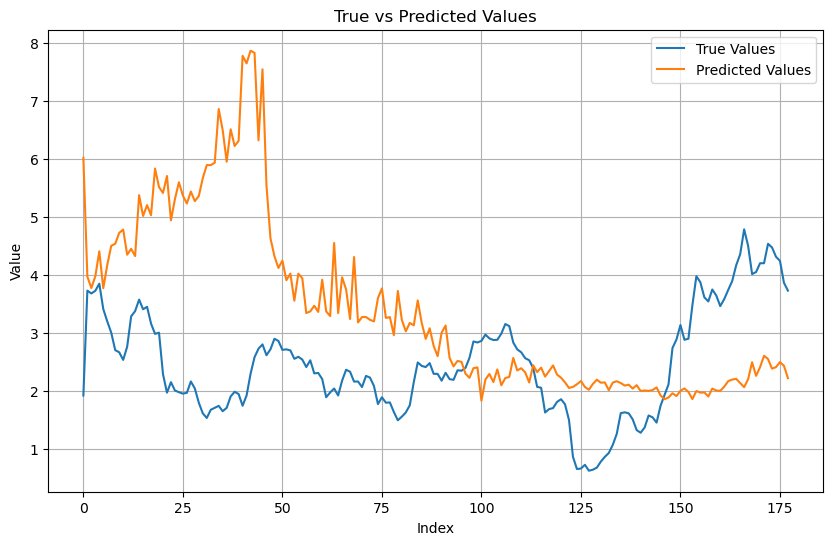

In [804]:
plt.figure(figsize=(10, 6)) 
plt.plot(true_values, label='True Values') 
plt.plot(pred_vals, label='Predicted Values') 
plt.xlabel('Index') 
plt.ylabel('Value') 
plt.title('True vs Predicted Values') 
plt.legend() 
plt.grid(True) 
plt.show()

In [805]:
len(y)

358

In [807]:
true_values

array([[1.926129  ],
       [3.7335484 ],
       [3.6842856 ],
       [3.7306452 ],
       [3.8536668 ],
       [3.4158065 ],
       [3.203     ],
       [3.0090322 ],
       [2.7080646 ],
       [2.6706667 ],
       [2.5396774 ],
       [2.7673333 ],
       [3.29      ],
       [3.3809679 ],
       [3.5785713 ],
       [3.4125807 ],
       [3.4546666 ],
       [3.1648388 ],
       [2.9883332 ],
       [3.0090322 ],
       [2.294516  ],
       [1.9746667 ],
       [2.1561291 ],
       [2.012     ],
       [1.9832258 ],
       [1.9580646 ],
       [1.9724138 ],
       [2.1680646 ],
       [2.0473332 ],
       [1.8012903 ],
       [1.6186666 ],
       [1.5387096 ],
       [1.68      ],
       [1.713     ],
       [1.7477419 ],
       [1.6553333 ],
       [1.713871  ],
       [1.9096774 ],
       [1.9903572 ],
       [1.9509678 ],
       [1.75      ],
       [1.926129  ],
       [2.3006666 ],
       [2.586129  ],
       [2.7329032 ],
       [2.807     ],
       [2.6203225 ],
       [2.722

In [814]:
y[179:357]

,month,yield_5yr_ahead
239,2004-12-01,3.600000
240,2005-01-01,3.733548
241,2005-02-01,3.684286
242,2005-03-01,3.730645
243,2005-04-01,3.853667
...,...,...
412,2019-05-01,4.478387
413,2019-06-01,4.317333
414,2019-07-01,4.246774
415,2019-08-01,3.869355


In [ ]:
#TEST LSTM, GRU, TRANSFORMER